In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ujjwalchowdhury/yoga-pose-classification")

print("Path to dataset files:", path)

100%|██████████| 15.0M/15.0M [00:00<00:00, 16.2MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/ujjwalchowdhury/yoga-pose-classification/versions/1


In [47]:
# prompt: import libraries for cnn project

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import cv2
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator
#Check if GPU is available
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
#Check tensorflow version
tf.__version__

Num GPUs Available:  1


'2.18.0'

In [7]:
image_list_downdog = []
image_list_goddess = []
image_list_plank = []
image_list_tree = []
image_list_warrior = []

for images in os.listdir(path+"/YogaPoses/Downdog"):
    if images.endswith(".png") or images.endswith(".jpg"):
        image_list_downdog.append(os.path.join(path+"/YogaPoses/Downdog",
                                             images))
for images in os.listdir(path+"/YogaPoses/Goddess"):
    if images.endswith(".png") or images.endswith(".jpg"):
        image_list_goddess.append(os.path.join(path+"/YogaPoses/Goddess",
                                             images))
for images in os.listdir(path+"/YogaPoses/Plank"):
    if images.endswith(".png") or images.endswith(".jpg"):
        image_list_plank.append(os.path.join(path+"/YogaPoses/Plank",
                                             images))
for images in os.listdir(path+"/YogaPoses/Tree"):
    if images.endswith(".png") or images.endswith(".jpg"):
        image_list_tree.append(os.path.join(path+"/YogaPoses/Tree",
                                             images))
for images in os.listdir(path+"/YogaPoses/Warrior2"):
    if images.endswith(".png") or images.endswith(".jpg"):
        image_list_warrior.append(os.path.join(path+"/YogaPoses/Warrior2",
                                             images))

In [9]:
print(len(image_list_downdog),
len(image_list_goddess),
len(image_list_plank),
len(image_list_tree),
len(image_list_warrior))

196 199 197 198 198


In [15]:
# prompt: show random images from lists

import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

def show_random_images(image_list,name, num_images=3):
  random_indices = random.sample(range(len(image_list)), num_images)
  plt.figure(figsize=(10, 10))
  for i, index in enumerate(random_indices):
    img = mpimg.imread(image_list[index])
    plt.subplot(1, num_images, i + 1)
    plt.title(name)
    plt.imshow(img)
    plt.axis('off')
  plt.show()


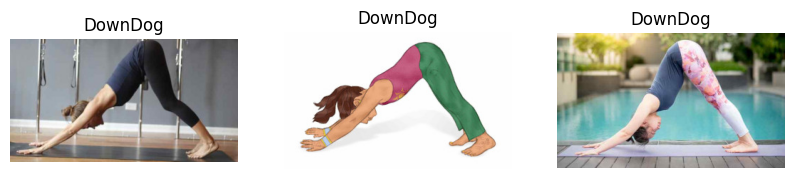

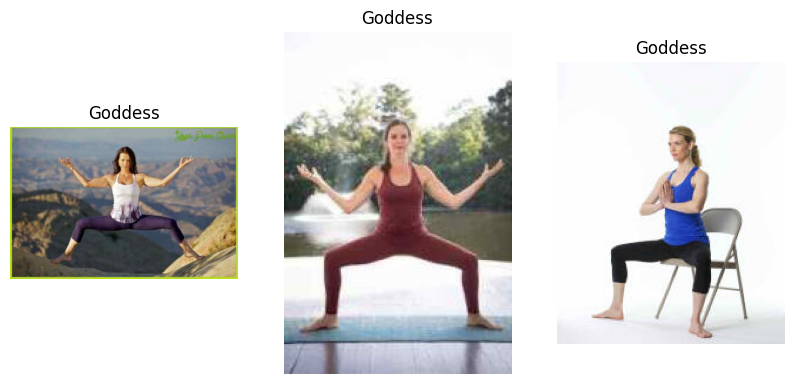

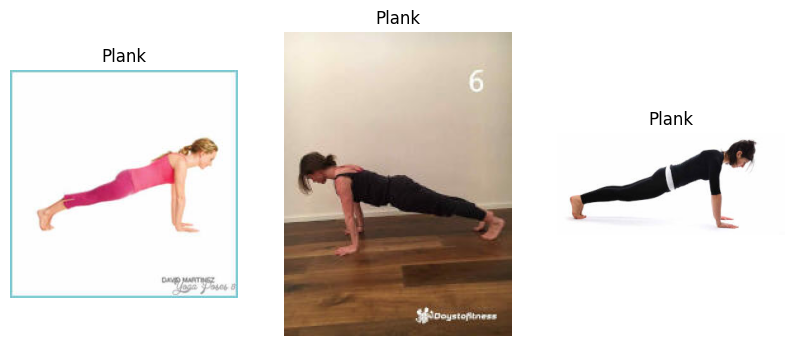

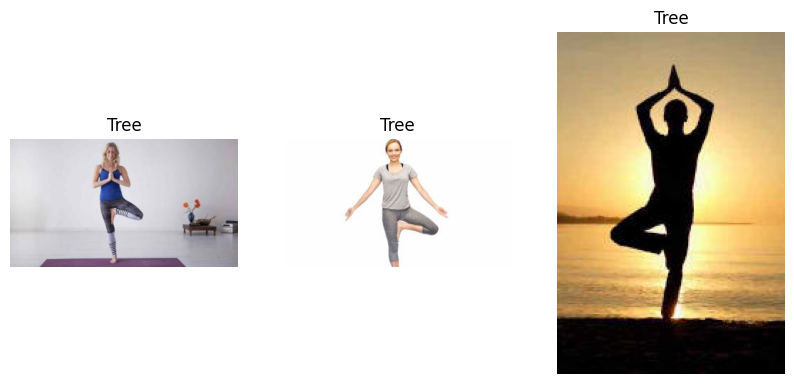

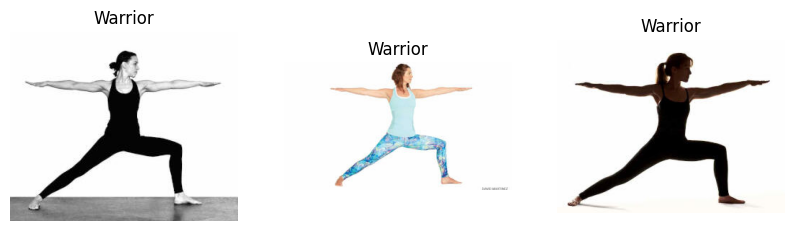

In [17]:
show_random_images(image_list_downdog,'DownDog')
show_random_images(image_list_goddess,'Goddess')
show_random_images(image_list_plank,'Plank')
show_random_images(image_list_tree,'Tree')
show_random_images(image_list_warrior,'Warrior')

In [31]:
# prompt: train test split lists

# Combine all image lists and create corresponding labels
image_paths = image_list_downdog + image_list_goddess + image_list_plank + image_list_tree + image_list_warrior
labels = ['Downdog'] * len(image_list_downdog) + ['Goddess'] * len(image_list_goddess) + ['Plank'] * len(image_list_plank) + ['Tree'] * len(image_list_tree) + ['Warrior'] * len(image_list_warrior)

# Split the data into training and testing sets
train_paths, test_paths, train_labels, test_labels = train_test_split(image_paths, labels, test_size=0.25, random_state=42)


In [32]:
# prompt: test_labels count with condition

# Count test_labels for specific poses
downdog_count = test_labels.count('Downdog')
goddess_count = test_labels.count('Goddess')
plank_count = test_labels.count('Plank')
tree_count = test_labels.count('Tree')
warrior_count = test_labels.count('Warrior')

print("Test labels count:")
print(f"Downdog: {downdog_count}")
print(f"Goddess: {goddess_count}")
print(f"Plank: {plank_count}")
print(f"Tree: {tree_count}")
print(f"Warrior: {warrior_count}")


Test labels count:
Downdog: 45
Goddess: 56
Plank: 50
Tree: 44
Warrior: 52


In [33]:
train_df=pd.DataFrame({'path':train_paths,'label':train_labels})
val_df=pd.DataFrame({'path':test_paths,'label':test_labels})

In [44]:
random_img_height = random.choice(image_list_downdog)
image= cv2.imread(random_img_height)
height, width= image.shape[:2]
print("The height is ", height)

print("The width is ", width)

The height is  204
The width is  320


In [55]:
Batch_size = 16
Img_height = 64
Img_width = 64

In [50]:
trainGenerator = ImageDataGenerator(rescale=1./255.)
valGenerator = ImageDataGenerator(rescale=1./255.)
testGenerator = ImageDataGenerator(rescale=1./255.)

In [51]:
trainDataset = trainGenerator.flow_from_dataframe(
  dataframe=train_df,
  class_mode="categorical",
  x_col="path",
  y_col="label",
  batch_size=Batch_size,
  seed=42,
  shuffle=True,
  target_size=(Img_height,Img_width) #set the height and width of the images
)
valDataset = trainGenerator.flow_from_dataframe(
  dataframe=val_df,
  class_mode="categorical",
  x_col="path",
  y_col="label",
  batch_size=Batch_size,
  seed=42,
  shuffle=True,
  target_size=(Img_height,Img_width) #set the height and width of the images
)

Found 741 validated image filenames belonging to 5 classes.
Found 247 validated image filenames belonging to 5 classes.


In [57]:
# prompt: cnn alexnet

def AlexNet(input_shape, num_classes):
    model = keras.Sequential(
        [
            keras.Input(shape=input_shape),
            layers.Conv2D(96, kernel_size=(11, 11), strides=4, padding="valid", activation="relu"),
            layers.MaxPooling2D(pool_size=(3, 3), strides=2),
            layers.BatchNormalization(),
            layers.Conv2D(256, kernel_size=(5, 5), padding="same", activation="relu"),
            layers.MaxPooling2D(pool_size=(3, 3), strides=2),
            layers.BatchNormalization(),
            layers.Conv2D(384, kernel_size=(3, 3), padding="same", activation="relu"),
            layers.BatchNormalization(),
            layers.Conv2D(384, kernel_size=(3, 3), padding="same", activation="relu"),
            layers.BatchNormalization(),
            layers.Conv2D(256, kernel_size=(3, 3), padding="same", activation="relu"),
            layers.MaxPooling2D(pool_size=(2,2), strides=2),
            layers.BatchNormalization(),
            layers.Flatten(),
            layers.Dense(4096, activation="relu"),
            layers.Dropout(0.5),
            layers.Dense(4096, activation="relu"),
            layers.Dropout(0.5),
            layers.Dense(num_classes, activation="softmax"),
        ]
    )
    return model

input_shape = (Img_height, Img_width, 3)
num_classes = 5  # Number of yoga poses

model = AlexNet(input_shape, num_classes)
model.summary()

model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])

# Train the model
epochs = 100  # You can adjust the number of epochs
history = model.fit(trainDataset, epochs=epochs, validation_data=valDataset)


# Evaluate the model
loss, accuracy = model.evaluate(valDataset, verbose=0)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")



Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_20 (Conv2D)                   │ (None, 14, 14, 96)          │          34,944 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_12 (MaxPooling2D)      │ (None, 6, 6, 96)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_20               │ (None, 6, 6, 96)            │             384 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_21 (Conv2D)                   │ (None, 6, 6, 256)           │         614,656 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_13 (MaxPooling2D)      │ (None, 2, 2, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_21               │ (None, 2, 2, 256)           │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_22 (Conv2D)                   │ (None, 2, 2, 384)           │         885,120 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_22               │ (None, 2, 2, 384)           │           1,536 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_23 (Conv2D)                   │ (None, 2, 2, 384)           │       1,327,488 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_23               │ (None, 2, 2, 384)           │           1,536 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_24 (Conv2D)                   │ (None, 2, 2, 256)           │         884,992 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_14 (MaxPooling2D)      │ (None, 1, 1, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_24               │ (None, 1, 1, 256)           │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_4 (Flatten)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_12 (Dense)                     │ (None, 4096)                │       1,052,672 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_8 (Dropout)                  │ (None, 4096)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_13 (Dense)                     │ (None, 4096)                │      16,781,312 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_9 (Dropout)                  │ (None, 4096)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_14 (Dense)                     │ (None, 5)                   │          20,4

 Total params: 21,607,173 (82.42 MB)

 Trainable params: 21,604,421 (82.41 MB)

 Non-trainable params: 2,752 (10.75 KB)

Epoch 1/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 12s 232ms/step - accuracy: 0.2614 - loss: 2.5073 - val_accuracy: 0.2105 - val_loss: 9.0371
Epoch 2/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 0.4829 - loss: 1.8729 - val_accuracy: 0.2105 - val_loss: 13.5018
Epoch 3/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - accuracy: 0.5650 - loss: 1.1491 - val_accuracy: 0.3279 - val_loss: 1.7095
Epoch 4/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 0.6570 - loss: 0.8465 - val_accuracy: 0.3563 - val_loss: 2.4448
Epoch 5/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - accuracy: 0.6973 - loss: 0.7952 - val_accuracy: 0.3158 - val_loss: 2.2432
Epoch 6/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.7206 - loss: 0.7310 - val_accuracy: 0.3684 - val_loss: 1.4568
Epoch 7/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - accuracy: 0.7176 - loss: 0.7364 - val_accuracy: 0.5304 - val_loss: 1.4101
Epoch 8/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - accuracy: 0.8037 - loss: 0.4842 - val_accuracy:

In [58]:
# prompt: model predict my img

from tensorflow.keras.preprocessing import image
import numpy as np

def predict_image(image_path):
    img = image.load_img(image_path, target_size=(Img_height, Img_width))
    x = image.img_to_array(img)
    x = np.expand_dims(x, axis=0)
    x = x / 255.0  # Normalize the image
    images = np.vstack([x])
    pred = model.predict(images, batch_size=10)
    predicted_class = np.argmax(pred)
    class_labels = ['Downdog', 'Goddess', 'Plank', 'Tree', 'Warrior'] # Ensure this order matches your model's training
    predicted_label = class_labels[predicted_class]
    print(f"Predicted Label: {predicted_label}")
    return predicted_label

# Example usage:
image_path = "/content/istockphoto-667293728-612x612.jpg" #replace with your image path.
predict_image(image_path)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Predicted Label: Tree


'Tree'

In [60]:
predict_image('/content/E117QWJN.jpg')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
Predicted Label: Goddess


'Goddess'

In [76]:
predict_image('/content/images.jpg')


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
Predicted Label: Plank


'Plank'

In [86]:
# prompt: cnn mobilenet

import numpy as np
import tensorflow as tf

IMG_SHAPE = (Img_height, Img_width, 3)

# Create the base model from the pre-trained model MobileNet V2
base_model = tf.keras.applications.MobileNetV2(input_shape=IMG_SHAPE,
                                               include_top=False,
                                               weights='imagenet')
base_model.trainable = False

# Add a classification head
global_average_layer = tf.keras.layers.GlobalAveragePooling2D()
prediction_layer = tf.keras.layers.Dense(num_classes, activation='softmax')

inputs = tf.keras.Input(shape=IMG_SHAPE)
x = base_model(inputs, training=False)
x = global_average_layer(x)
x = tf.keras.layers.Dropout(0.2)(x)
outputs = prediction_layer(x)
model = tf.keras.Model(inputs, outputs)

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

# Train the model
epochs = 35 # You can adjust the number of epochs
history = model.fit(trainDataset, epochs=epochs, validation_data=valDataset)

# Evaluate the model
loss, accuracy = model.evaluate(valDataset, verbose=0)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")


<ipython-input-86-2852729ca622>:9: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(input_shape=IMG_SHAPE,


Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_9 (InputLayer)           │ (None, 64, 64, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ mobilenetv2_1.00_224 (Functional)    │ (None, 2, 2, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_1           │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_11 (Dropout)                 │ (None, 1280)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_16 (Dense)                     │ (None, 5)                   │           6,405 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,264,389 (8.64 MB)

 Trainable params: 6,405 (25.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/35
24/24 ━━━━━━━━━━━━━━━━━━━━ 15s 348ms/step - accuracy: 0.2600 - loss: 1.9300 - val_accuracy: 0.5466 - val_loss: 1.0944
Epoch 2/35
24/24 ━━━━━━━━━━━━━━━━━━━━ 11s 44ms/step - accuracy: 0.6531 - loss: 0.9166 - val_accuracy: 0.6802 - val_loss: 0.8156
Epoch 3/35
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - accuracy: 0.7342 - loss: 0.6867 - val_accuracy: 0.7530 - val_loss: 0.6623
Epoch 4/35
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - accuracy: 0.8291 - loss: 0.4923 - val_accuracy: 0.7773 - val_loss: 0.6234
Epoch 5/35
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 0.8160 - loss: 0.4714 - val_accuracy: 0.7814 - val_loss: 0.5436
Epoch 6/35
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 0.8609 - loss: 0.4021 - val_accuracy: 0.7895 - val_loss: 0.5347
Epoch 7/35
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - accuracy: 0.8969 - loss: 0.3270 - val_accuracy: 0.8016 - val_loss: 0.5003
Epoch 8/35
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step - accuracy: 0.9215 - loss: 0.2733 - val_accuracy: 0.8178 